In [1]:
!pip -q install pandas numpy matplotlib seaborn openpyxl

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

sns.set(style="whitegrid", context="talk")
np.random.seed(42)

In [3]:
networks = ["DMN", "Salience", "FPN", "Limbic", "Visual", "Somatomotor"]
domains = [
    "working_memory",
    "attention",
    "cognitive_flexibility",
    "episodic_memory"
]

rows = []

for domain in domains:
    for net in networks:
        score = {
            "DMN": 0.58,
            "Salience": 0.66,
            "FPN": 0.72,
            "Limbic": 0.54,
            "Visual": 0.40,
            "Somatomotor": 0.35
        }[net] + np.random.normal(0, 0.05)

        rows.append([domain, net, score])

df = pd.DataFrame(rows, columns=["domain", "network", "association_score"])
df.head()

,domain,network,association_score
0,working_memory,DMN,0.604836
1,working_memory,Salience,0.653087
2,working_memory,FPN,0.752384
3,working_memory,Limbic,0.616151
4,working_memory,Visual,0.388292


In [4]:
summary = (
    df.groupby("network")["association_score"]
    .mean()
    .reset_index()
    .sort_values("association_score", ascending=False)
)

summary

,network,association_score
1,FPN,0.718987
3,Salience,0.626295
0,DMN,0.597623
2,Limbic,0.555969
5,Visual,0.379464
4,Somatomotor,0.327370


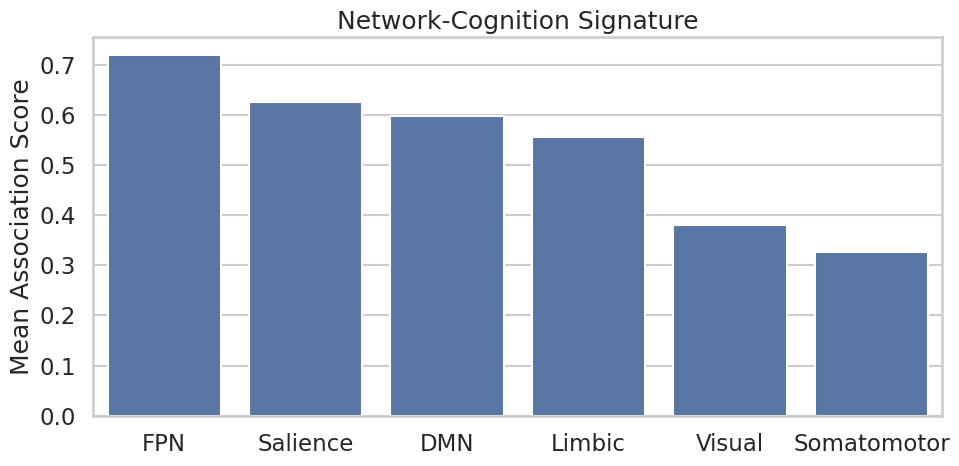

In [5]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=summary,
    x="network",
    y="association_score"
)

plt.xlabel("")
plt.ylabel("Mean Association Score")
plt.title("Network-Cognition Signature")
plt.tight_layout()
plt.savefig("figures/02_network_signature.png", dpi=300)
plt.show()

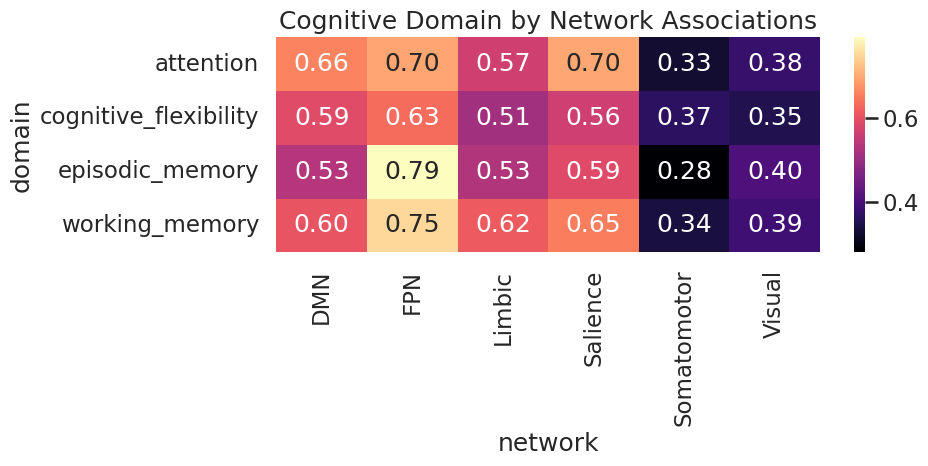

In [6]:
pivot = df.pivot(index="domain", columns="network", values="association_score")

plt.figure(figsize=(10,5))

sns.heatmap(
    pivot,
    cmap="magma",
    annot=True,
    fmt=".2f"
)

plt.title("Cognitive Domain by Network Associations")
plt.tight_layout()
plt.savefig("figures/02_domain_heatmap.png", dpi=300)
plt.show()

In [7]:
summary.to_csv("outputs/02_network_cognition_summary.csv", index=False)
df.to_csv("outputs/02_domain_network_scores.csv", index=False)

summary

,network,association_score
1,FPN,0.718987
3,Salience,0.626295
0,DMN,0.597623
2,Limbic,0.555969
5,Visual,0.379464
4,Somatomotor,0.327370
